# Dimensional Reduction

Name: Wesley Stevick

Date: 

1. Build a matrix where the rows are small analyzable chunks (larger than a word, less than a book). The columns will be the Strong's numbers and the values are the frequency of those lemmas within your chunk.

In [1]:
import pandas as pd
import numpy as np

nt = pd.read_pickle("pickles/nt.pickle")
dictionary = pd.read_pickle("pickles/dictionary.pickle")

In [2]:
# English description of the thing being frequency analyzed
# this is used in print statements and chart labels
word = "part"
count_var = "pos"
# word = "term"
# count_var = "strong"

nt["pos"] = nt["parsed_rmac"].str.split(" - ").str[0]

nt["book - chapter"] = nt["book"].astype(str) + " - " + nt["chapter"].astype(str)

freq_table = pd.crosstab(nt["book - chapter"], nt[count_var]).astype(float)

# divide the term count in each book by the number of terms in that book, to get frequencies
freq_table /= freq_table.sum(axis=1).values[:, None]
assert np.allclose(freq_table.sum(axis=1), 1)
freq_table.describe()

pos,Adjective,Adverb or adverb and particle combined,Aramaic transliterated word (indeclinable),Conditional particle or conjunction,Conjunction or conjunctive particle,Correlative or interrogative pronoun,Correlative pronoun,Definite article,Demonstrative pronoun,Hebrew transliterated word (indeclinable),...,Interrogative pronoun,Noun,"Particle, disjunctive particle",Personal pronoun,Possessive adjective,Preposition,Reciprocal pronoun,Reflexive pronoun,Relative pronoun,Verb
count,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,0.062964,0.031575,0.000254,0.006505,0.120019,0.000167,0.000861,0.143053,0.012046,0.000956,...,0.003563,0.206703,0.028593,0.077203,0.000822,0.078438,0.000861,0.003138,0.011665,0.198054
std,0.027474,0.012178,0.000963,0.006417,0.018571,0.000639,0.001711,0.030103,0.007131,0.001990,...,0.003763,0.038714,0.015708,0.029441,0.001968,0.021356,0.002142,0.004108,0.007007,0.038461
min,0.018391,0.002336,0.000000,0.000000,0.057214,0.000000,0.000000,0.037634,0.000000,0.000000,...,0.000000,0.122490,0.000000,0.009146,0.000000,0.027439,0.000000,0.000000,0.000000,0.099502
25%,0.044253,0.023333,0.000000,0.001787,0.108293,0.000000,0.000000,0.125973,0.006664,0.000000,...,0.000000,0.178611,0.018045,0.056803,0.000000,0.062072,0.000000,0.000000,0.006348,0.167372
50%,0.057352,0.030508,0.000000,0.005019,0.120173,0.000000,0.000000,0.141641,0.011526,0.000000,...,0.002625,0.207090,0.026711,0.078717,0.000000,0.074543,0.000000,0.002031,0.011278,0.200704
75%,0.073945,0.038396,0.000000,0.009174,0.133220,0.000000,0.001578,0.158353,0.016470,0.001273,...,0.005406,0.236795,0.036662,0.094543,0.000000,0.091879,0.000222,0.004533,0.016142,0.227407
max,0.202128,0.076220,0.006192,0.035714,0.168519,0.004769,0.016807,0.236395,0.034884,0.012251,...,0.018797,0.333333,0.091314,0.194779,0.016064,0.144279,0.019169,0.032362,0.033816,0.284884


2. Apply PCA to this matrix and interpret the results. Interpret top loadings—what terms drive the first three principal components?

In [3]:
from sklearn.decomposition import PCA

pca = PCA()
pcs = pca.fit_transform(freq_table)
pcs = pd.DataFrame(pcs, columns=pca.get_feature_names_out()).set_index(freq_table.index)

In [4]:
components = pd.DataFrame(pca.components_.T, columns="loading_" + pcs.columns)
components.set_index(freq_table.columns, inplace=True)

In [5]:
for ic, col in enumerate(components.columns[:3]):
    print(f"The {word}s that drive component {ic} are")
    # print the terms with the highest absolute value in the PCi loading
    by_impact_ix = abs(components[col]).argsort()[::-1]
    for it in by_impact_ix[:5]:  # show five terms per component
        thing = components.index[it]
        if word == "term":
            print(
                f" - {dictionary.loc[thing, 'original']} - {dictionary.loc[thing, 'kjv']} ({components[col].iloc[it]:.2g})"
            )
        else:
            print(f" - {thing} ({components[col].iloc[it]:.2g})")
    print()

The parts that drive component 0 are
 - Noun (0.65)
 - Verb (-0.62)
 - Personal pronoun (-0.29)
 - Adjective (0.21)
 - Preposition (0.16)

The parts that drive component 1 are
 - Adjective (0.57)
 - Definite article (-0.54)
 - Personal pronoun (-0.49)
 - Verb (0.27)
 - Preposition (-0.17)

The parts that drive component 2 are
 - Definite article (0.7)
 - Personal pronoun (-0.48)
 - Preposition (-0.43)
 - Verb (0.27)
 - Indeclinable proper noun (0.099)



3. Create a scree plot and interpret the plot. 

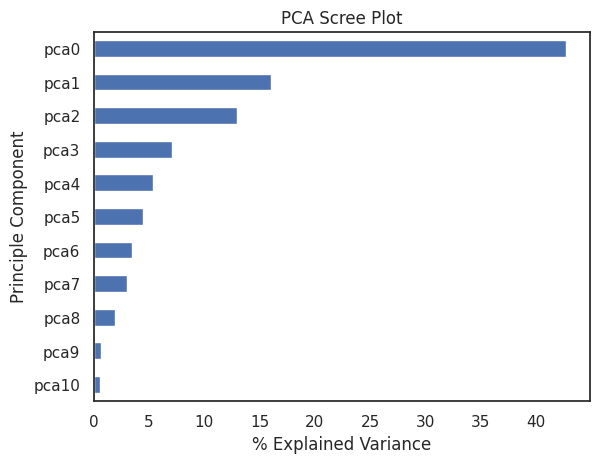

In [6]:
import seaborn as sns

sns.set(style="white")

ax = pd.Series(pca.explained_variance_ratio_ * 100, pca.get_feature_names_out())[
    10::-1
].plot.barh()
ax.set_ylabel("Principle Component")
ax.set_xlabel("% Explained Variance")
ax.set_title("PCA Scree Plot");

This reminds me of a zipfs distribution. The component 1 explains aobut half the variance as component 0, component 2 explains about a third the variance of component 0, component 3 explains aobut a fourth the variance of component 0, etc. I'm not exactly sure what this distrubution means, other than that the first couple of components predict most of the variation in the data.

Additionally I want to note that when I first made this plot component 0 explained more than 60% of the variance, and the others followed the zipf distribution. I guessed that this was because I was working directly with *counts*, not *frequency*, and that component 0 was just looking at the length of the book. After normalizing things look much nicer.

4. Plot results in PCA space and interpret the plot. Use color to plot trends you might expect to see (e.g. author, genre, etc.).

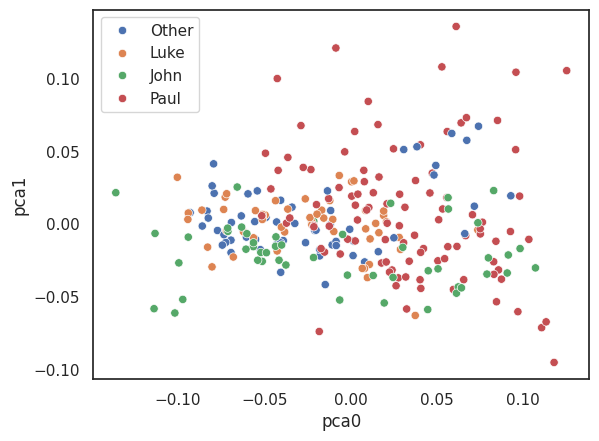

In [7]:
author_map = new_testament_authors = {
    40: "Matthew",
    41: "Mark",
    42: "Luke",
    43: "John",
    44: "Luke",  # Acts
    45: "Paul",  # Romans
    46: "Paul",  # 1 Corinthians
    47: "Paul",  # 2 Corinthians
    48: "Paul",  # Galatians
    49: "Paul",  # Ephesians
    50: "Paul",  # Philippians
    51: "Paul",  # Colossians
    52: "Paul",  # 1 Thessalonians
    53: "Paul",  # 2 Thessalonians
    54: "Paul",  # 1 Timothy
    55: "Paul",  # 2 Timothy
    56: "Paul",  # Titus
    57: "Paul",  # Philemon
    58: "Paul",  # Hebrews (ChatGPT says "Unknown, traditionally Paul")
    59: "James",
    60: "Peter",  # 1 Peter
    61: "Peter",  # 2 Peter
    62: "John",  # 1 John
    63: "John",  # 2 John
    64: "John",  # 3 John
    65: "Jude",
    66: "John",  # Revelation
}
chapter_authors = (
    pcs.index.to_series().str.split(" - ").str[0].astype(int).replace(author_map)
)
top_authors = chapter_authors.value_counts().index[:3].values
sns.scatterplot(
    pcs,
    x="pca0",
    y="pca1",
    hue=np.where(chapter_authors.isin(top_authors), chapter_authors, "Other"),
);

5. Quantify separation between clusters. e.g. separation between Pauline books and Johannine books. Do this for 3 different clusters.

In [8]:
top_authors

array(['Paul', 'Luke', 'John'], dtype=object)

In [9]:
is_by_top_author = chapter_authors.isin(top_authors)
freq_table[is_by_top_author].groupby(chapter_authors[is_by_top_author]).describe()

pos            Adjective                                                    \
                   count      mean       std       min       25%       50%   
book - chapter                                                               
John                50.0  0.056133  0.023206  0.022530  0.038222  0.051550   
Luke                52.0  0.054340  0.013336  0.024862  0.043895  0.053711   
Paul               100.0  0.072256  0.033673  0.025000  0.047777  0.063149   

pos                                Adverb or adverb and particle combined  \
                     75%       max                                  count   
book - chapter                                                              
John            0.070736  0.109718                                   50.0   
Luke            0.065233  0.083582                                   52.0   
Paul            0.085719  0.202128                                  100.0   

pos                       ... Relative pronoun             Verb            \
                    mean  ...              75%       max  count      mean   
book - chapter            ...                                               
John            0.027257  ...         0.012606  0.033816   50.0  0.197846   
Luke            0.027634  ...         0.015058  0.031683   52.0  0.223528   
Paul            0.034217  ...         0.018326  0.031657  100.0  0.173358   

pos                                                                         
                     std       min       25%       50%       75%       max  
book - chapter                                                              
John            0.040335  0.123232  0.162803  0.204045  0.232994  0.284884  
Luke            0.026702  0.151361  0.204446  0.223345  0.245030  0.271277  
Paul            0.030601  0.099502  0.154070  0.172508  0.196544  0.258883  

[3 rows x 208 columns]

In [10]:
def get_ss(data):
    """
    Varience with one-dimensional data is total squared distance from the value.
    Likewise, with n-dimensional data, varience is total squared (Euclidean) distance from the mean *point*
    """
    mean = data.mean(axis=0)
    deltas = data - mean
    squared_lengths = (deltas * deltas).sum(axis=0)
    return squared_lengths.sum(axis=0)


# calculate mean squares between/within the two groups to quantify seperation
for i, a1 in enumerate(top_authors):
    cluster1 = freq_table[chapter_authors == a1]
    ss1 = get_ss(cluster1)
    for a2 in top_authors[i + 1 :]:
        cluster2 = freq_table[chapter_authors == a2]
        cluster2 = freq_table[chapter_authors == a2]
        ss2 = get_ss(cluster2)
        ss_total = get_ss(pd.concat([cluster1, cluster2], axis=0))
        ss_within = ss1 + ss2
        ss_between = ss_total - ss_within
        ms_between = ss_between / (2 - 1)
        ms_within = ss_within / (len(cluster1) + len(cluster2) - 2)
        f = ms_between / ms_within
        print(f"Between {a1} and {a2}, f-statistic is {f}")

Between Paul and Luke, f-statistic is 24.386756537895472
Between Paul and John, f-statistic is 17.17661807329049
Between Luke and John, f-statistic is 6.773232433252386


When using terms, Paul and John are most different, followed by Paul and Luke.

When using POSs, Paul and Luke are most different, followed by Paul and John.

6. Repeat steps 1-5 but with the parts of speech feature instead of the Strong's numbers.

Rather than copy/pasting all of the above code I modified the table at the top. You can switch whether the steps are performed with terms or parts of speech by commenting and uncommenting lines in 1.

I thought about performing some grouping - i.e. putting all parts called "noun" together in one category called "noun," but decided to leave them in there as in the rmac, due to my lack of experience with Greek grammar.

7. Use a KNN with a k-fold cross validation for hyper parameter tuning to predict the author of a given pericope (small chunk you must define).

In [11]:
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Jude breaks stratified split, because he only has one chapter
jude_id = "65 - 1"
chapter_authors.drop(index=jude_id, inplace=True, errors="ignore")
freq_table.drop(index=jude_id, inplace=True, errors="ignore")

chapters_train, chapters_test = train_test_split(
    freq_table.index, test_size=0.2, stratify=chapter_authors, random_state=1234
)

k_scores = pd.Series(dtype=float)
n_splits = 10
for k in range(1, int(chapters_train.shape[0] * 4 / 5)):
    k_scores.loc[k] = 0.0
    for kf_train, validate in KFold(n_splits=n_splits).split(chapters_train):
        chapters_kf_train = chapters_train[kf_train]
        chapters_validate = chapters_train[validate]
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(freq_table.loc[chapters_kf_train], chapter_authors[chapters_kf_train])
        k_scores.loc[k] += accuracy_score(
            chapter_authors[chapters_validate],
            clf.predict(freq_table.loc[chapters_validate]),
        )
k_scores /= n_splits
k_scores

1      0.590952
2      0.562143
3      0.604524
4      0.647857
5      0.657619
         ...   
160    0.386667
161    0.386667
162    0.386667
163    0.386667
164    0.386667
Length: 164, dtype: float64

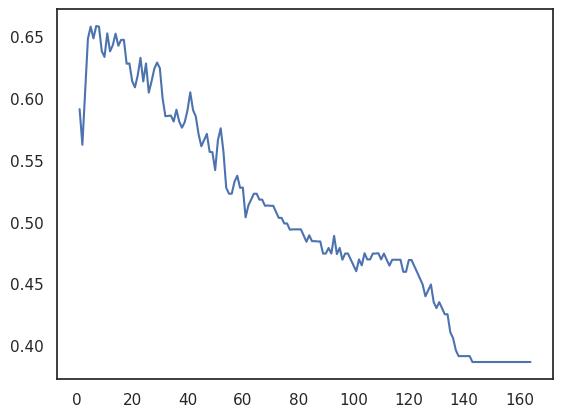

In [12]:
k_scores.plot();

In [13]:
k_scores.sort_values()[::-1][:10]

7     0.658095
5     0.657619
8     0.657619
11    0.652143
14    0.651905
6     0.648095
4     0.647857
17    0.646905
16    0.646905
13    0.642619
dtype: float64

In [14]:
# k = 7  # for parts of speech
k = 10  # I don't trust the success of k=1 and k=3
clf = KNeighborsClassifier(n_neighbors=k)
clf.fit(freq_table.loc[chapters_train], chapter_authors[chapters_train])
true = chapter_authors[chapters_test]
pred = clf.predict(freq_table.loc[chapters_test])
print("Accuracy:", accuracy_score(true, pred))
print("Misclassified")
for errloc in np.where(true != pred)[0]:
    print(f"\tmistook {true.iloc[errloc]} for {pred[errloc]}")

Accuracy: 0.6538461538461539
Misclassified
	mistook Paul for Luke
	mistook Paul for Luke
	mistook Peter for Paul
	mistook Mark for Luke
	mistook Paul for Luke
	mistook Matthew for Paul
	mistook Peter for Paul
	mistook Matthew for Luke
	mistook John for Luke
	mistook John for Luke
	mistook Matthew for John
	mistook Matthew for John
	mistook John for Luke
	mistook Luke for John
	mistook Mark for Luke
	mistook Matthew for Luke
	mistook Matthew for Luke
	mistook James for Luke


Perform LDA instead of PCA on the matrix in 1.

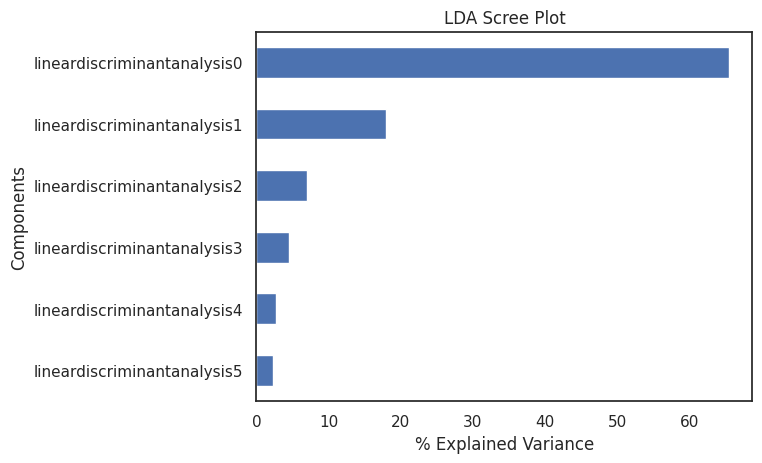

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(freq_table, chapter_authors)
ax = pd.Series(lda.explained_variance_ratio_ * 100, lda.get_feature_names_out())[
    10::-1
].plot.barh()
ax.set_ylabel("Components")
ax.set_xlabel("% Explained Variance")
ax.set_title("LDA Scree Plot");